
### 📝 Самостоятельные задания

#### Задание 1. Анализ выбросов
Постройте **ящики с усами (boxplots)** для каждого признака с разбивкой по видам. Определите, есть ли выбросы у вида *Iris virginica* по признаку `sepal width`. Какой процент наблюдений выходит за границы усов?

<details>
<summary>💡 Подсказка</summary>
Используйте `sns.boxplot(x='species', y='sepal width (cm)', data=df)`. Границы усов = Q1 - 1.5×IQR и Q3 + 1.5×IQR.
</details>

#### Задание 2. Сравнение дисперсий
Рассчитайте **коэффициент вариации** (стандартное отклонение / среднее × 100%) для каждого признака. Какой признак наиболее изменчив относительно своего среднего значения? Почему это важно для нормализации данных?

<details>
<summary>💡 Подсказка</summary>
`cv = (df[col].std() / df[col].mean()) * 100`. Высокий CV (>30%) указывает на сильную изменчивость — такие признаки часто требуют масштабирования.
</details>

#### Задание 3. Создание нового признака
Создайте производный признак **«соотношение длины и ширины лепестка»** (`petal_length / petal_width`). Постройте гистограмму этого признака по видам. Улучшает ли он разделение классов по сравнению с исходными признаками?

<details>
<summary>💡 Подсказка</summary>
`df['petal_ratio'] = df['petal length (cm)'] / df['petal width (cm)']`. Используйте `sns.violinplot` для сравнения распределений.
</details>

---

### 📚 Рекомендуемые материалы

1. **Оригинальная статья Фишера (1936):**  
   Fisher, R. A. (1936). The use of multiple measurements in taxonomic problems. *Annals of Eugenics*, 7(2), 179–188.  
   DOI: [10.1111/j.1469-1809.1936.tb02137.x](https://doi.org/10.1111/j.1469-1809.1936.tb02137.x)

2. **Современный учебник по EDA:**  
   Bruce, P., Bruce, A., & Gedeck, P. (2020). *Practical Statistics for Data Scientists* (2nd ed.). O'Reilly. Глава 1.

3. **Документация seaborn:**  
   [ seaborn.pydata.org/tutorial](https://seaborn.pydata.org/tutorial.html) — официальный туториал по визуализации.

---



### ⚠️ Рекомендации по академической честности

- Сохраняйте историю изменений ноутбука через **«Файл → Версия → Показать историю версий»** в Colab.
- При использовании кода из внешних источников **обязательно указывайте ссылку** в комментарии:
  ```python
  # Адаптировано из: https://scikit-learn.org/stable/auto_examples/datasets/plot_iris_dataset.html
  ```
- Для цитирования датасета в отчёте используйте формат **APA**:
  > Pedregosa, F., et al. (2011). Scikit-learn: Machine learning in Python. *Journal of Machine Learning Research*, 12, 2825–2830. Датасет: `sklearn.datasets.load_iris()`.

---

### ✅ Чек-лист для сдачи работы
- [ ] Установлено `np.random.seed(42)` в начале ноутбука
- [ ] Присутствуют все 4 типа анализа: `.head()`, `.info()`, `.describe()`, визуализации
- [ ] Ноутбук содержит текстовые ячейки с интерпретацией графиков (не только код)
- [ ] Выполнено разделение на X и y
- [ ] Ноутбук сохранён в Google Drive с именем `ML_Practice_1_1_Фамилия.ipynb`
- [ ] Добавлен блок «Выводы» с 2–3 предложениями об особенностях датасета Iris

Удачи в первой практике!

**Решение ДЗ 1**

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 6 columns):
 #   Column             Non-Null Count  Dtype   
---  ------             --------------  -----   
 0   sepal length (cm)  150 non-null    float64 
 1   sepal width (cm)   150 non-null    float64 
 2   petal length (cm)  150 non-null    float64 
 3   petal width (cm)   150 non-null    float64 
 4   target             150 non-null    int64   
 5   species            150 non-null    category
dtypes: category(1), float64(4), int64(1)
memory usage: 6.3 KB
None
       sepal length (cm)  sepal width (cm)  petal length (cm)  \
count         150.000000        150.000000         150.000000   
mean            5.843333          3.057333           3.758000   
std             0.828066          0.435866           1.765298   
min             4.300000          2.000000           1.000000   
25%             5.100000          2.800000           1.600000   
50%             5.800000          3.000000    

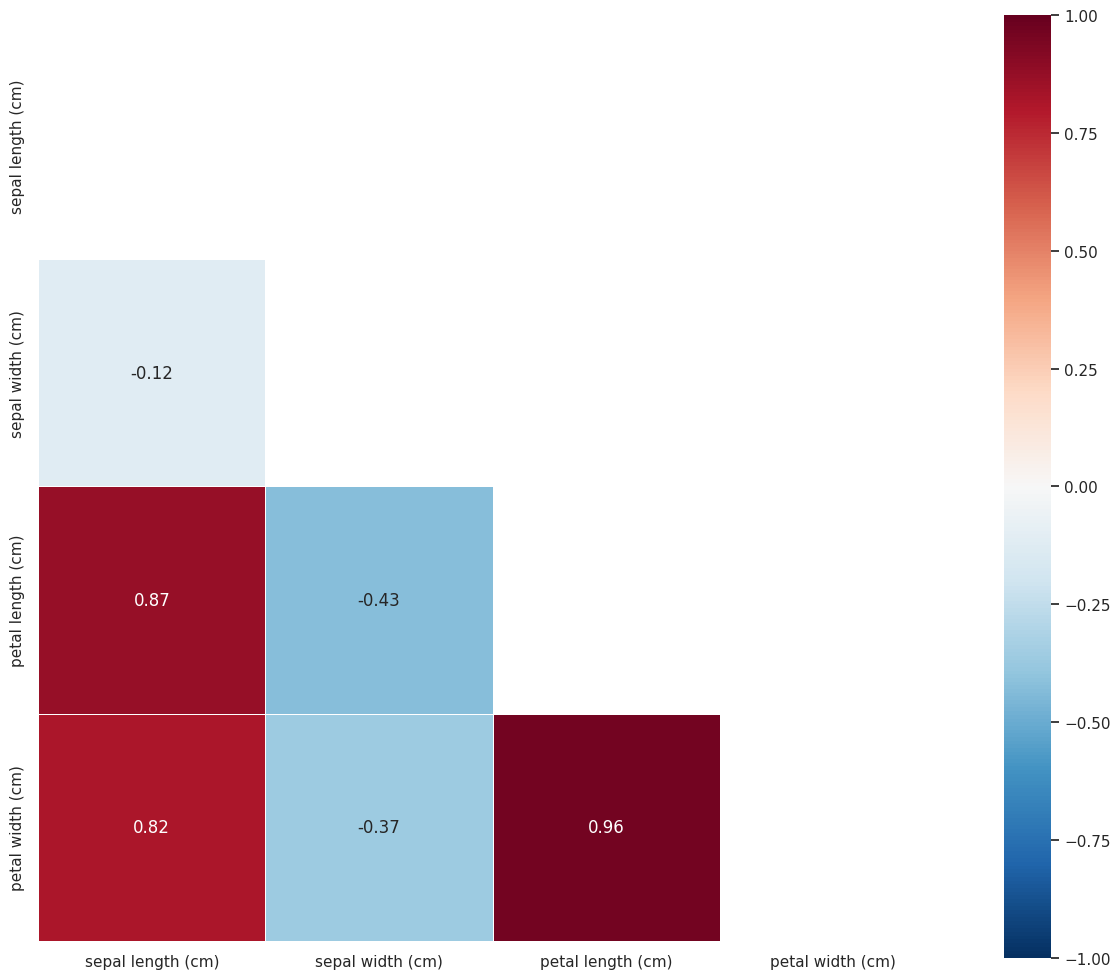

Задание 1


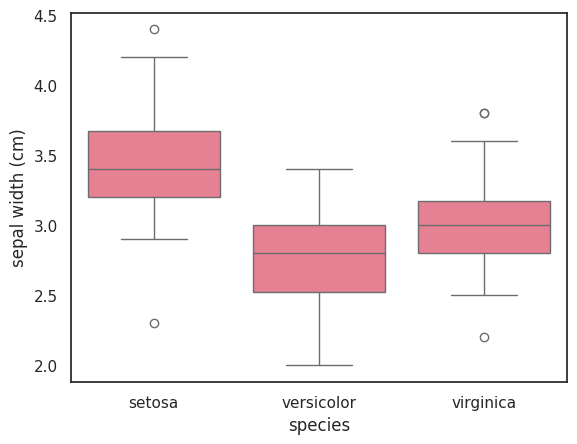

Границы усов: 2.237499999999999 до 3.7375000000000007
Количество выбросов: 3
Процент выбросов: 6.0 %
Задание 2
             Признак       CV %
0   petal width (cm)  63.555114
1  petal length (cm)  46.974407
2   sepal width (cm)  14.256420
3  sepal length (cm)  14.171126
Наиболее изменчивый признак: petal width (cm) 63.555114143441884 %
Задание 3


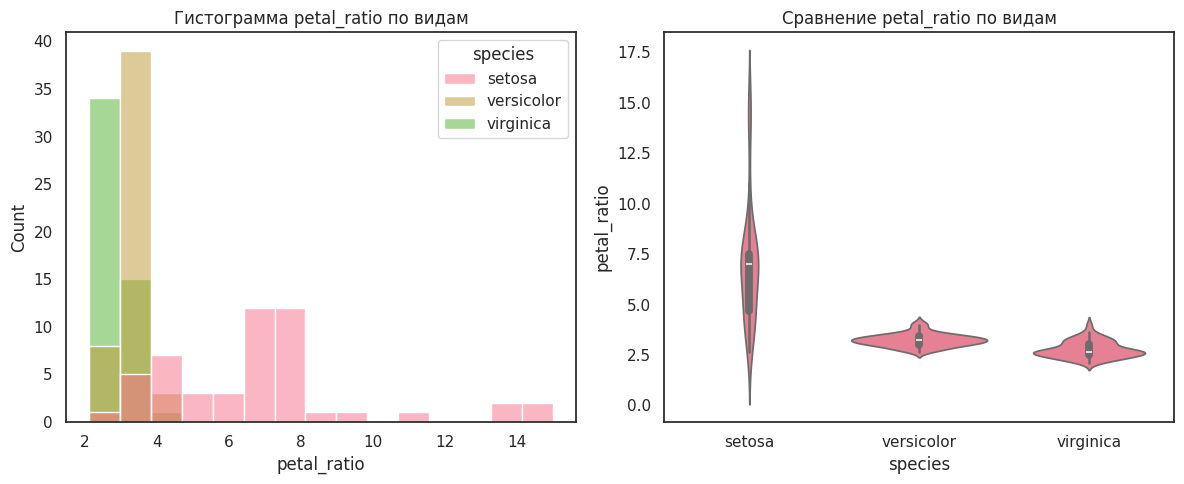

Длина лепестка: 3.7496844863972503
Ширина лепестка: 3.242762774129531
Отношение длина/ширина: 1.0215588492827343
Улучшение: -70.78107817703369 %


In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_iris


def task3_get_sep(data, col):
    setosa = data[data['species'] == 'setosa'][col].mean()
    versicolor = data[data['species'] == 'versicolor'][col].mean()
    virginica = data[data['species'] == 'virginica'][col].mean()
    # CКО
    setosa_s = data[data['species'] == 'setosa'][col].std()
    versicolor_s = data[data['species'] == 'versicolor'][col].std()
    virginica_s = data[data['species'] == 'virginica'][col].std()
    # Коэффициенты разделимости
    sep1 = abs(setosa - versicolor) / (setosa_s + versicolor_s)
    sep2 = abs(setosa - virginica) / (setosa_s + virginica_s)
    sep3 = abs(versicolor - virginica) / (versicolor_s + virginica_s)
    return (sep1 + sep2 + sep3) / 3

# 1) Постройте ящики с усами (boxplots) для каждого признака с разбивкой по видам.
# Определите, есть ли выбросы у вида Iris virginica по признаку sepal width.
# Какой процент наблюдений выходит за границы усов?

np.random.seed(42)

iris = load_iris()

df = pd.DataFrame(data=iris.data, columns=iris.feature_names)

df['target'] = iris.target

df['species'] = pd.Categorical.from_codes(
    iris.target,
    iris.target_names
)

print(df.info())

print(df.describe())

# Матрица корреляций
plt.figure(figsize=(12, 10))

corr_matrix = df.iloc[:, :4].corr()

# Маска для скрытия верхнего треугольника матрицы
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

sns.heatmap(
    corr_matrix,
    mask=mask,
    annot=True,
    fmt=".2f",
    cmap='RdBu_r',
    vmin=-1,
    vmax=1,
    center=0,
    square=True,
    linewidths=.5
)

plt.tight_layout()
plt.show()

print('Задание 1')

sns.boxplot(
    x='species',
    y='sepal width (cm)',
    data=df
)

plt.show()

virginica = df[df['species'] == 'virginica']['sepal width (cm)']

q1 = virginica.quantile(0.25)

q3 = virginica.quantile(0.75)

# Межквартильный размах
iqr = q3 - q1

# Нижняя граница выбросов
down = q1 - 1.5 * iqr

# Верхняя граница выбросов
up = q3 + 1.5 * iqr

# Поиск выбросов
outliers = []

for val in virginica:
    if val < down or val > up:
        outliers.append(val)

percent = (len(outliers) / len(virginica)) * 100

print('Границы усов:', down, 'до', up)
print('Количество выбросов:', len(outliers))
print('Процент выбросов:', percent, '%')

print('Задание 2')

# 2) Рассчитайте коэффициент вариации (стандартное отклонение / среднее × 100%) для каждого признака.
# Какой признак наиболее изменчив относительно своего среднего значения?
# Почему это важно для нормализации данных?

# Высокий коэффициент вариации означает что в данных большой разброс
# Если у нескольких признаков слишком разный коэф. вариации,
# то необходима нормализация. Без нормализации такие признаки могут
# по-разному влиять на алгоритм

cols = [
    'sepal length (cm)',
    'sepal width (cm)',
    'petal length (cm)',
    'petal width (cm)'
]

cv_list = []

# Расчёт коэффициента вариации для каждого признака
for col in cols:

    std = df[col].std()
    mean = df[col].mean()

    cv = (std / mean) * 100

    cv_list.append([col, cv])

cv_df = pd.DataFrame(
    cv_list,
    columns=['Признак', 'CV %']
)

cv_df = cv_df.sort_values(
    'CV %',
    ascending=False
)

cv_df = cv_df.reset_index(drop=True)

print(cv_df)

print(
    'Наиболее изменчивый признак:',
    cv_df['Признак'][0],
    cv_df['CV %'][0],
    '%'
)

print('Задание 3')

# 3) Создайте производный признак «соотношение длины и ширины лепестка» (petal_length / petal_width).
# Постройте гистограмму этого признака по видам.
# Улучшает ли он разделение классов по сравнению с исходными признаками?

# Создаём новый признак
df['petal_ratio'] = (
    df['petal length (cm)']
    /
    df['petal width (cm)']
)

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)

sns.histplot(
    data=df,
    x='petal_ratio',
    hue='species',
    bins=15
)

plt.title('Гистограмма petal_ratio по видам')

plt.subplot(1, 2, 2)

sns.violinplot(
    data=df,
    x='species',
    y='petal_ratio'
)

plt.title('Сравнение petal_ratio по видам')

plt.tight_layout()
plt.show()

# Разделимость исходных признаков
pl = task3_get_sep(df, 'petal length (cm)')
pw = task3_get_sep(df, 'petal width (cm)')

# Разделимость нового признака
pr = task3_get_sep(df, 'petal_ratio')

# Средняя разделимость старых признаков
old = (pl + pw) / 2

# Улучшение
improve = ((pr - old) / old) * 100

print('Длина лепестка:', pl)
print('Ширина лепестка:', pw)
print('Отношение длина/ширина:', pr)
print('Улучшение:', improve, '%')

# Новый признак гораздо хуже исходных признаков
# Он хуже различает классы, потому что значения разных видов
# ирисов по этому признаку стали более похожими друг на друга

# Выводы (особенности датасета Iris):
# Выбросов практически нет.
# Сильная корреляция между длиной и шириной лепестка.
# Это говорит о том что несколько признаков несут схожие данные


### 📝 Самостоятельные задания (выполнить без подглядывания в код выше)

#### Задание 1. Выявление мультиколлинеарности
Найдите **все пары признаков** с абсолютной корреляцией |r| > 0.7. Создайте таблицу из 3 столбцов: `Признак_1`, `Признак_2`, `Корреляция`. Сколько таких пар существует? Какой признак участвует в наибольшем числе сильных корреляций?

<details>
<summary>💡 Подсказка</summary>
Используйте метод `.corr()` для получения матрицы корреляций, затем примените маску `abs(corr) > 0.7`. Для подсчёта пар используйте `np.where()` или итерацию по треугольной матрице.
</details>

#### Задание 2. Анализ асимметрии распределений
Рассчитайте **коэффициент асимметрии (skewness)** для каждого признака с помощью `scipy.stats.skew()`. Какие 3 признака имеют наибольшую положительную асимметрию (правый хвост)? Почему это важно для применения алгоритмов, чувствительных к распределению (например, SVM с ядром RBF)?

<details>
<summary>💡 Подсказка</summary>
Положительная асимметрия означает, что большинство значений сосредоточено слева с длинным правым хвостом. Такие признаки часто требуют логарифмического преобразования перед обучением модели.
</details>

#### Задание 3. Создание «идеального» разделяющего признака
Сконструируйте новый признак как **линейную комбинацию** двух существующих:  
`wine_quality_index = 0.6 * df['flavanoids'] + 0.4 * df['color_intensity']`  
Постройте график распределения этого индекса по регионам. Улучшает ли он разделение классов по сравнению с исходными признаками? Подтвердите вывод количественно через расчёт **коэффициента разделения классов** (разница средних / сумма стандартных отклонений).

<details>
<summary>💡 Подсказка</summary>
Для количественной оценки используйте:  
`separation = abs(mean_class1 - mean_class2) / (std_class1 + std_class2)`  
Чем выше значение, тем лучше разделение.
</details>

### ⚠️ Академическая честность и оформление

- При цитировании датасета используйте формат **APA**:  
  > Pedregosa, F., et al. (2011). Scikit-learn: Machine learning in Python. *Journal of Machine Learning Research*, 12, 2825–2830. Датасет: `sklearn.datasets.load_wine()`.

- Если вы используете код из документации или статей, укажите источник в комментарии:  
  ```python
  # Расчёт асимметрии адаптирован из документации SciPy
  # https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.skew.html
  ```

- Сохраняйте ноутбук с именем: `ML_Practice_1_2_Фамилия.ipynb`

---

### ✅ Чек-лист для сдачи самостоятельной работы

- [ ] Ноутбук начинается с `np.random.seed(42)`
- [ ] Присутствуют все 3 типа анализа: структурный (`.info()`), статистический (`.describe()`), визуальный (графики)
- [ ] Тепловая карта корреляций содержит аннотации значений
- [ ] Выполнены все 3 самостоятельных задания с кодом и интерпретацией результатов
- [ ] В конце ноутбука добавлен блок **«Выводы»** (3–4 предложения о ключевых особенностях датасета Wine)
- [ ] Ноутбук сохранён в Google Drive и доступен для проверки

---

### 💡 Совет для продвинутых студентов
Попробуйте применить **Principal Component Analysis (PCA)** для визуализации данных в 2D-пространстве. Удастся ли отделить все три региона на графике первых двух главных компонент? Это задание подготовит вас к практике 2.1 по понижению размерности.

Удачи в самостоятельной работе! 🍷📊

**Решение ДЗ 2**

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 178 entries, 0 to 177
Data columns (total 15 columns):
 #   Column                        Non-Null Count  Dtype   
---  ------                        --------------  -----   
 0   alcohol                       178 non-null    float64 
 1   malic_acid                    178 non-null    float64 
 2   ash                           178 non-null    float64 
 3   alcalinity_of_ash             178 non-null    float64 
 4   magnesium                     178 non-null    float64 
 5   total_phenols                 178 non-null    float64 
 6   flavanoids                    178 non-null    float64 
 7   nonflavanoid_phenols          178 non-null    float64 
 8   proanthocyanins               178 non-null    float64 
 9   color_intensity               178 non-null    float64 
 10  hue                           178 non-null    float64 
 11  od280/od315_of_diluted_wines  178 non-null    float64 
 12  proline                       178 non-null    floa

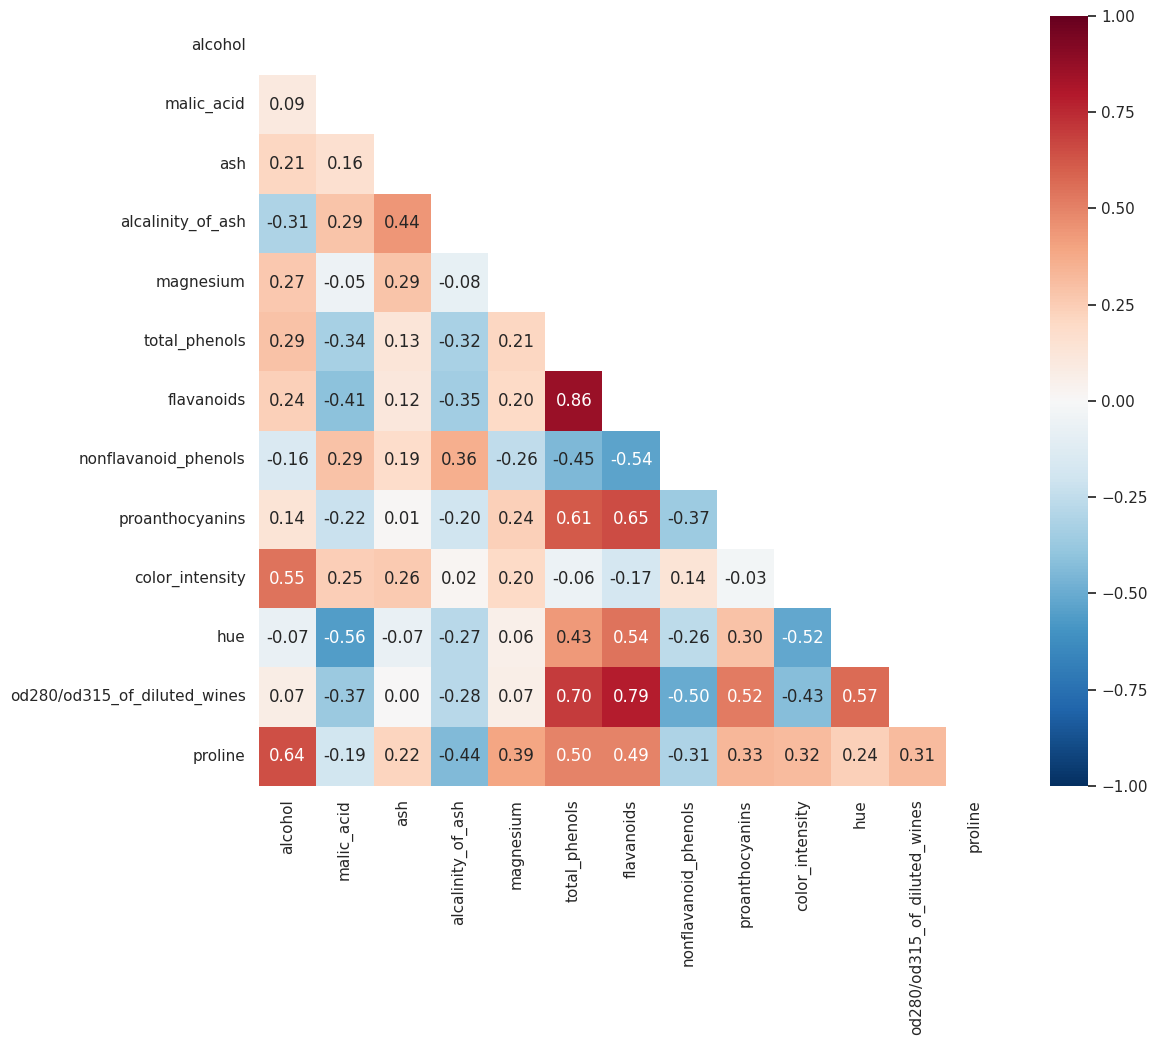

Задача 1
       Признак_1                     Признак_2  Корреляция
0  total_phenols                    flavanoids       0.865
1     flavanoids  od280/od315_of_diluted_wines       0.787
Количество пар: 2
Признак с наибольшим числом связей: flavanoids
Задача 2
           Признак  Коэффициент асимметрии
4        magnesium                1.088915
1       malic_acid                1.030869
9  color_intensity                0.861248
Задача 3


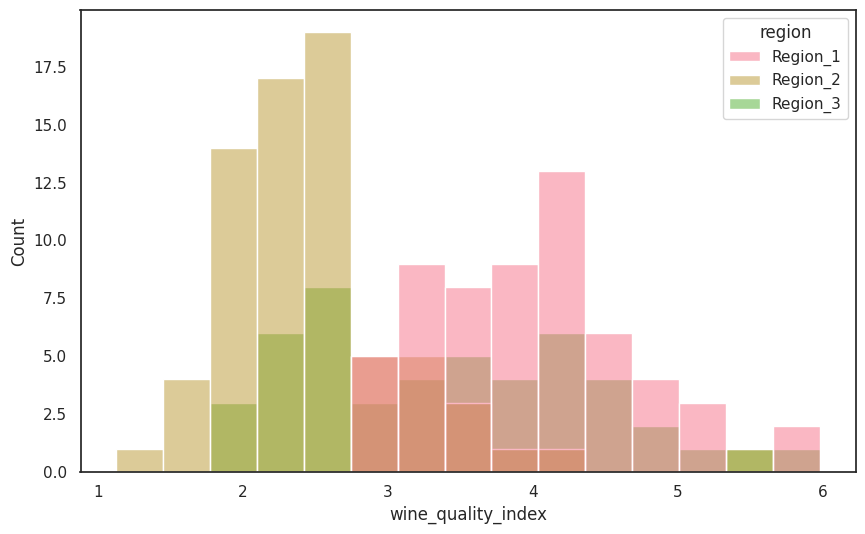

Улучшение разделения классов: -51.00930111820685 %


In [6]:


import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_wine
from scipy.stats import skew
from collections import Counter

def task3_split_coef(data, feature):
    region0 = data[data['target'] == 0][feature]
    region1 = data[data['target'] == 1][feature]
    region2 = data[data['target'] == 2][feature]

    m0, m1, m2 = region0.mean(), region1.mean(), region2.mean()
    s0, s1, s2 = region0.std(), region1.std(), region2.std()

    sep01 = abs(m0 - m1) / (s0 + s1)
    sep02 = abs(m0 - m2) / (s0 + s2)
    sep12 = abs(m1 - m2) / (s1 + s2)

    return (sep01 + sep02 + sep12) / 3

np.random.seed(42)

wine = load_wine()

df = pd.DataFrame(data=wine.data, columns=wine.feature_names)
df['target'] = wine.target
df['region'] = pd.Categorical.from_codes(
    wine.target,
    [f'Region_{i+1}' for i in range(3)]
)

print(df.info())
print(df.describe())

# Корреляционная матрица
plt.figure(figsize=(12, 10))
corr_matrix = df.iloc[:, :-2].corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

sns.heatmap(
    corr_matrix,
    mask=mask,
    annot=True,
    fmt=".2f",
    cmap='RdBu_r',
    vmin=-1,
    vmax=1,
    center=0
)

plt.show()

print('Задача 1')

# 1) Найдите все пары признаков с абсолютной корреляцией |r| > 0.7.
# Создайте таблицу из 3 столбцов: Признак_1, Признак_2, Корреляция.
# Сколько таких пар существует?
# Какой признак участвует в наибольшем числе сильных корреляций?

# Отбираем только признаки
features = [col for col in df.columns if col not in ['target', 'region']]

# Ищем сильные корреляции
corr = df[features].corr()
pairs = []

for i in range(len(corr.columns)):
    for j in range(i + 1, len(corr.columns)):
        val = corr.iloc[i, j]
        if abs(val) > 0.7:
            pairs.append([corr.columns[i], corr.columns[j], round(val, 3)])

# Определяем наиболее связанный признак
all_feats = []
for p in pairs:
    all_feats.extend([p[0], p[1]])

most = Counter(all_feats).most_common(1)[0]

print(pd.DataFrame(pairs, columns=['Признак_1', 'Признак_2', 'Корреляция']))
print(f'Количество пар: {len(pairs)}')
print(f'Признак с наибольшим числом связей: {most[0]}')

print('Задача 2')

# 2) Рассчитайте коэффициент асимметрии (skewness) для каждого признака с помощью scipy.stats.skew().
# Какие 3 признака имеют наибольшую положительную асимметрию (правый хвост)?
# Почему это важно для применения алгоритмов, чувствительных к распределению (например, SVM с ядром RBF)?

# Признаки с большой ассиметрией могут ухудшать качество разделения классов

# Анализ асимметрии распределений
skew_list = []
for col in features:
    skew_list.append([col, skew(df[col])])

skew_df = pd.DataFrame(skew_list, columns=['Признак', 'Коэффициент асимметрии'])
skew_df = skew_df.sort_values('Коэффициент асимметрии', ascending=False)

print(skew_df.head(3))

print('Задача 3')

# 3) Сконструируйте новый признак как линейную комбинацию двух существующих:
# wine_quality_index = 0.6 * df['flavanoids'] + 0.4 * df['color_intensity']
# Постройте график распределения этого индекса по регионам.
# Улучшает ли он разделение классов по сравнению с исходными признаками?
# Подтвердите вывод количественно через расчёт коэффициента разделения классов (разница средних / сумма стандартных отклонений).

# Новый признак ухудшает распределение классов
# При сложении часть различий между классами сглаживается
# Уменьшилась информативность

df['wine_quality_index'] = (0.6 * df['flavanoids'] + 0.4 * df['color_intensity'])

plt.figure(figsize=(10, 6))
sns.histplot(data=df, x='wine_quality_index', hue='region', bins=15)
plt.show()

# Проверяем улучшилась ли разделимость классов
flav = task3_split_coef(df, 'flavanoids')
color = task3_split_coef(df, 'color_intensity')
new_sep = task3_split_coef(df, 'wine_quality_index')

old_avg = (flav + color) / 2

print(f'Улучшение разделения классов: {((new_sep - old_avg) / old_avg) * 100} %')

# Выводы (особенности датасета Wine):
# Есть признаки с высокой корреляцией и асимметричным распределением
# Некотороые показатели хорошо разделяют классы вин